# Trial modes on the neuromodulator syllables

The trial clustering of `paper-individuality/3_trial_modes/clustering_trial_syllables_watershed.ipynb`
(one-hot syllables per bin → PCA → UMAP → KDE → watershed), now as functions in `Functions/trial_modes.py`,
run on the NM syllable file.

These syllables are **left paw + wheel, k=8, own state space** — not the same paw states as the proficient
both-paw syllables — so these trial modes are fitted fresh and their numbers do not correspond to the
proficient `17_trial_waterclust` modes.

In [1]:
import sys, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'paper-individuality'))
from Functions import trial_modes as tm
import paper_style as ps
ps.use('paper')

DATA = REPO / 'paper-individuality' / 'data' / 'neuromodulators'
RUN = 'left_paw_wheel_k8_own_lick-100ms'
SYLLABLE_FILE = DATA / f'{RUN}_neuromodulators_8_k_10_bin_syllables_06-10-2026'
STATES_DIR = DATA / f'states_files_{RUN}'
OUT = DATA / f'trial_modes_{RUN}'   # cached result: trials table + fitted models

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters (defaults = the original notebook)

In [2]:
PARAMS = dict(
    encoding='factored',     # 'factored': paw one-hot (minus ref_paw) + whisk + lick per bin; 'onehot': 32 codes per bin
    ref_paw=1,               # paw state dropped in 'factored' (the notebook's binarized_9d_ref2)
    n_pca=None,              # None = all components, as the notebook (PCA is then only a rotation)
    random_state=42,
    res=150,                 # KDE grid
    kde_max_points=50_000,   # KDE fitted on a subsample; None = all trials (slow at ~400k)
    threshold_pct=60,        # KDE percentile below which is background
    min_distance=10,         # watershed peak spacing (grid pixels) -> sets how many modes you get
    footprint_radius=2,
)
RECOMPUTE = False

In [3]:
syllables = pd.read_parquet(SYLLABLE_FILE)
if OUT.exists() and not RECOMPUTE:
    trials = pd.read_parquet(OUT / 'trials.pqt')
    with open(OUT / 'fit.pkl', 'rb') as f:
        res = pickle.load(f)
    assert res['params'] == {**res['params'], **PARAMS}, 'cached fit used other PARAMS: set RECOMPUTE = True'
    print('loaded cached fit')
else:
    trials, res = tm.cluster_trials(syllables, **PARAMS)
    OUT.mkdir(exist_ok=True)
    trials.to_parquet(OUT / 'trials.pqt')
    with open(OUT / 'fit.pkl', 'wb') as f:  # the UMAP reducer holds the whole training matrix (~0.5 GB): not saved
        pickle.dump({k: v for k, v in res.items() if k not in ('reducer', 'embedding')}, f)
n_modes = int(trials['trial_cluster'].max())
no_emb = trials['embedding_x'].isna()
print(f"{len(trials)} trials with all 4 epochs, {trials['session'].nunique()} sessions, {n_modes} modes")
print(f"{no_emb.mean():.1%} not embedded (a NaN syllable bin), "
      f"{(~no_emb & trials['trial_cluster'].isna()).mean():.1%} embedded but on the KDE background")

loaded cached fit
394839 trials with all 4 epochs, 533 sessions, 14 modes
5.9% not embedded (a NaN syllable bin), 3.5% embedded but on the KDE background


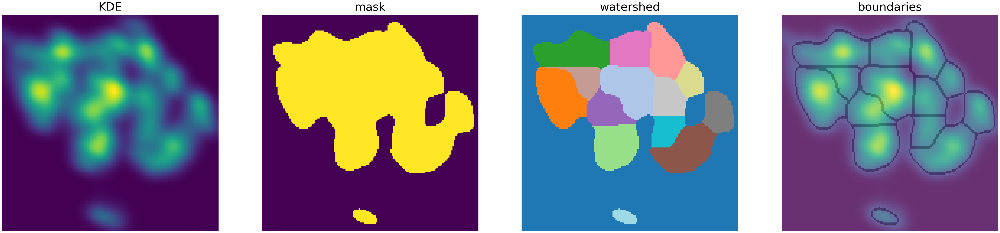

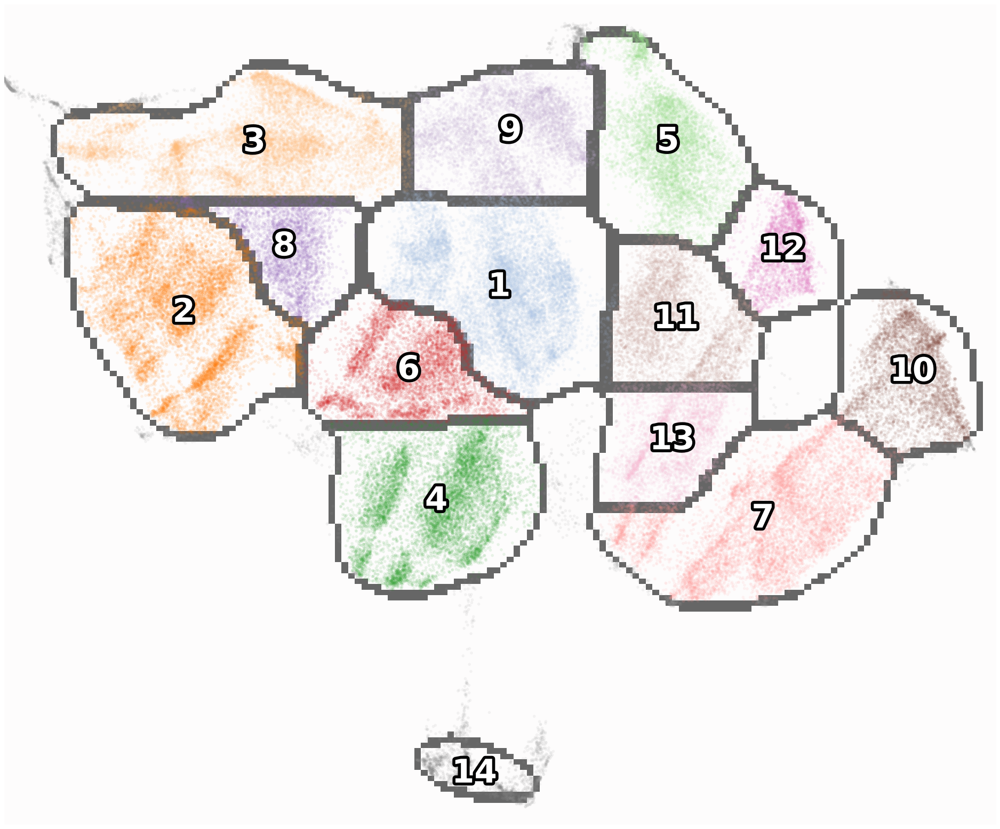

In [4]:
tm.plot_watershed(res);
tm.plot_clusters(trials, res);

## Session metadata (NM) and trial variables

In [5]:
qc = pd.read_csv(REPO / 'neuromodulators' / 'NM_pose_qc_eids.csv')
qc['NM'] = qc['target_NM'].str.split(',').apply(lambda t: '+'.join(dict.fromkeys(t)))
mouse_nm = qc.groupby('subject')['NM'].agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
trials['NM'] = trials['session'].map(qc.set_index('eid')['NM']).fillna(trials['mouse_name'].map(mouse_nm))

# trial variables from the states files (choice is mirrored there -- see 0_data_overview -- relabelled here)
cols = ['correct', 'choice', 'contrast', 'block', 'reaction', 'response', 'elongation', 'trial_id', 'session']
tv = pd.concat([pd.read_parquet(f, columns=cols).dropna(subset=['trial_id']).drop_duplicates('trial_id')
                for f in sorted(STATES_DIR.glob('*_states_file_*'))], ignore_index=True)
tv['choice'] = tv['choice'].replace({'left': 'right', 'right': 'left'})
trials = trials.merge(tv, on=['session', 'trial_id'], how='left')
print('trials without trial variables:', trials['correct'].isna().sum())
nm_order = trials.drop_duplicates('mouse_name')['NM'].value_counts().index.tolist()

trials without trial variables: 0


## Paw-state colours: left paw + wheel

The paper's state-palette rule (`ps.state_palette`), as written by `3.3_wavelet_clusters_uniform.ipynb`
for exactly these states (`state_palette.csv` in the states folder the syllables were built from):
**lightness = vigor** (states are numbered by vigor, 0 stillest), **violet = left-paw-led,
teal = wheel-led**, chroma = how far the state leans. Loaded into `paper_style` so its syllable
plots (`ps.syllable_histogram`, `ps.whisk_lick_panel`) draw in it. These syllables carry no
relabelling (`relabel: null` in the run's `_config.json`), so syllable paw digit = state.

In [6]:
import json
cfg = json.loads((STATES_DIR / '_config.json').read_text())
assert cfg['relabel'] is None, 'syllable paw digits are relabelled: map them before plotting'
STATE_TABLE = pd.read_csv(pathlib.Path(cfg['states_dir']) / 'state_palette.csv', index_col='state')
assert STATE_TABLE['vigor'].is_monotonic_increasing, 'states are expected numbered by vigor'

LEAN = 0.1   # |paw - wheel| power gap under which a state is called balanced

def lean(g):
    return 'paw-led' if g > LEAN else 'wheel-led' if g < -LEAN else 'both'

# point paper_style's paw-state constants at this state set (read at call time by its plot functions)
ps.PAW_STATE_COLORS = STATE_TABLE['colour'].tolist()
ps.PAW_VIGOR_ORDER = list(STATE_TABLE.index)
ps.SYLLABLE_COLORS = ps.PAW_STATE_COLORS + ps.SYLLABLE_COLORS[-2:]
ps.SYLLABLE = dict(zip(ps.SYLLABLE_NAMES, ps.SYLLABLE_COLORS))

def state_legend(target, ncol=8, **kw):
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=STATE_TABLE.loc[k, 'colour'], label=f"{k} {lean(STATE_TABLE.loc[k, 'gap'])}")
               for k in STATE_TABLE.index]
    handles.append(Patch(facecolor='white', edgecolor=ps.NODATA_EDGE, hatch=ps.NODATA_HATCH, label='no data'))
    kw.setdefault('loc', 'upper center'); kw.setdefault('bbox_to_anchor', (0.5, 0.02))
    return target.legend(handles=handles, ncol=ncol, frameon=False,
                         title='Left paw + wheel state (dark = vigorous)', **kw)

STATE_TABLE.assign(lean=STATE_TABLE['gap'].map(lean)).round(3)

,vigor,left_paw power,wheel power,share,gap,colour,lean
state,,,,,,,
0,-0.644,-0.640,-0.651,0.322,0.011,#EDE4F4,both
1,-0.233,-0.244,-0.211,0.242,-0.033,#A8C0BA,both
2,0.138,0.088,0.239,0.161,-0.151,#7AAAA0,wheel-led
3,0.500,0.540,0.421,0.099,0.119,#9484A0,paw-led
4,0.790,0.966,0.438,0.069,0.528,#9663B9,paw-led
5,0.914,0.708,1.325,0.070,-0.617,#047B6C,wheel-led
6,1.895,2.308,1.070,0.018,1.237,#7B06AF,paw-led
7,2.049,2.072,2.001,0.020,0.071,#342A3C,both


## What each mode looks like

`ps.syllable_histogram`, as in `2_pre-trial/syllable_composition.ipynb`: one stacked column per bin = the
composition of paw states across the mode's trials at that moment, stacked pale-still (top) to
dark-vigorous. Under it, P(whisking) as a band and P(licking) as a line (`ps.whisk_lick_panel`).
Modes are ordered by accuracy, so engaged-looking modes come first.

Below each mode, its **psychometric** (P(right choice) by signed contrast) and **chronometric** curve
(median reaction time = first movement − go cue, log scale), split by block (`ps.BLOCK` colours).
Each point is the mean ± SEM over mice of the per-mouse value; a mouse contributes to a point only with
≥ `MIN_TRIALS_POINT` trials of that mode at that contrast and block, so sparse modes have gaps rather than
noisy points. Choice is the relabelled one (true stimulus side reported), and no-go trials are left out.

In [7]:
MIN_TRIALS_POINT = 5
BLOCKS = [0.2, 0.5, 0.8]
X_SCALE = 'linear'   # 'linear': contrast in % (IBL standard); 'categorical': the 9 levels evenly spaced,
                     # which spreads out the low contrasts but makes every curve look shallower

flip = {'left': 'right', 'right': 'left'}
go = trials[trials['choice'].isin(['left', 'right']) & trials['block'].round(3).isin(BLOCKS)].copy()
go['block'] = go['block'].round(3)
stim_side = np.where(go['correct'] == 1, go['choice'], go['choice'].map(flip))
go['signed_contrast'] = (100 * go['contrast'] * np.where(stim_side == 'right', 1, -1)).round(2)
go['right_choice'] = (go['choice'] == 'right').astype(float)
CONTRASTS = sorted(go['signed_contrast'].unique())          # zero contrast lands on 0 whatever its side
XPOS = {c: (c if X_SCALE == 'linear' else i) for i, c in enumerate(CONTRASTS)}

def curves(d, value, stat):
    # per mouse, then mean and SEM over mice -> (block, signed_contrast) x [mean, sem, n_mice]
    per_mouse = (d.groupby(['mouse_name', 'block', 'signed_contrast'])[value]
                 .agg([stat, 'size']).query('size >= @MIN_TRIALS_POINT')[stat])
    return per_mouse.groupby(['block', 'signed_contrast']).agg(['mean', 'sem', 'size'])

def curve_panel(ax, table):
    for blk in BLOCKS:
        if blk not in table.index.get_level_values('block'):
            continue
        t = table.loc[blk]
        x = [XPOS[c] for c in t.index]
        ax.errorbar(x, t['mean'], yerr=t['sem'].fillna(0), color=ps.BLOCK[blk], marker='o', ms=2.5,
                    lw=1, capsize=0, label=ps.BLOCK_LABEL[blk])
    ends = [CONTRASTS[0], 0.0, CONTRASTS[-1]]
    ax.set_xticks([XPOS[c] for c in ends], [f'{c:g}' for c in ends])

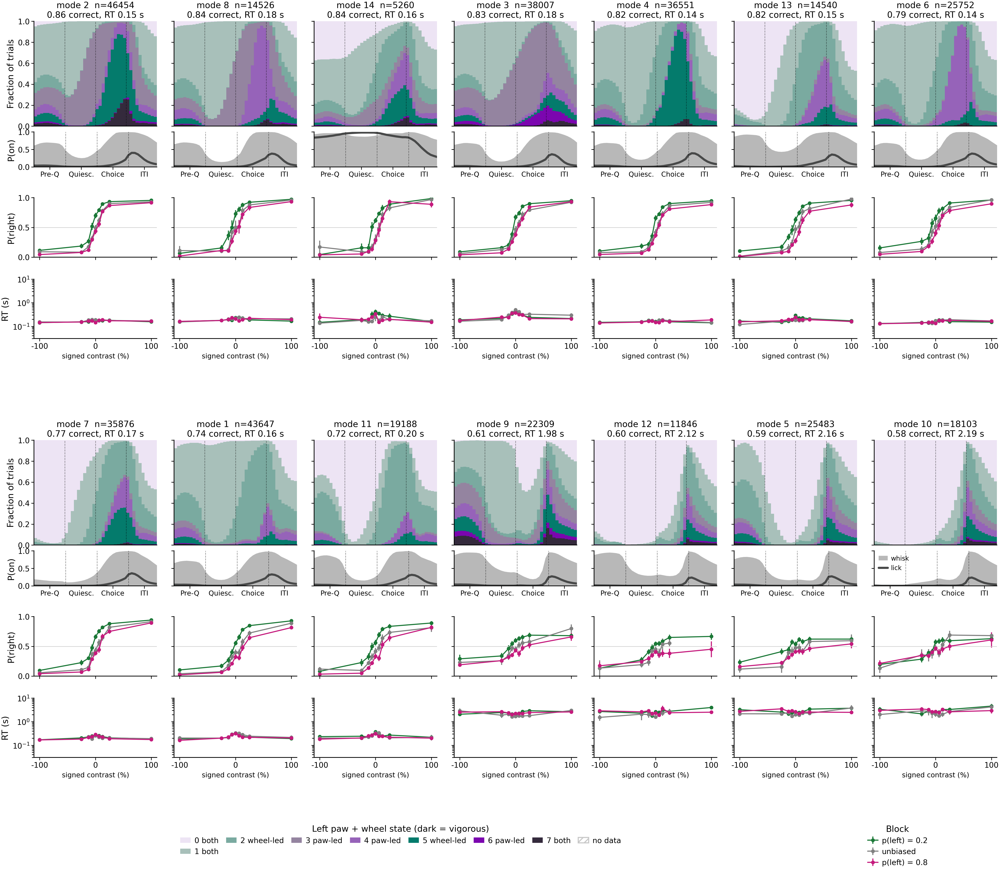

In [8]:
mode_summary = (trials.dropna(subset=['trial_cluster'])
                .groupby('trial_cluster')
                .agg(n=('correct', 'size'), frac_correct=('correct', 'mean'),
                     median_reaction=('reaction', 'median'), median_elongation=('elongation', 'median')))
mode_order = mode_summary.sort_values('frac_correct', ascending=False).index.astype(int).tolist()
rt_lim = (go['reaction'].clip(lower=0.03).quantile(0.01), 10)

ncol = 7
nrow = int(np.ceil(len(mode_order) / ncol))
fig = plt.figure(figsize=(2.3 * ncol, 6.2 * nrow))
outer = fig.add_gridspec(nrow, ncol, hspace=0.32, wspace=0.14)
for i, k in enumerate(mode_order):
    # rows 2 and 4 are spacers: the syllable pair stays tight, the two curve panels get room for ticks
    inner = outer[i // ncol, i % ncol].subgridspec(6, 1, height_ratios=[3, 1, 0.55, 1.7, 0.3, 1.7], hspace=0.12)
    ax, ax_wl = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    ax_psy, ax_chr = fig.add_subplot(inner[3]), fig.add_subplot(inner[5])

    _, codes = tm.trial_matrix_from_trials(trials[trials['trial_cluster'] == k])
    ps.syllable_histogram(codes, ax=ax)
    ps.whisk_lick_panel(codes, ax=ax_wl)
    for a in (ax, ax_wl):
        ps.epoch_lines(a, codes.shape[1])
    m = mode_summary.loc[k]
    ax.set_title(f"mode {k}  n={int(m['n'])}\n{m['frac_correct']:.2f} correct, RT {m['median_reaction']:.2f} s",
                 fontsize=plt.rcParams['font.size'])
    ax.set_xticks([])
    ax_wl.set_xticks([5, 15, 25, 35], ps.EPOCH_SHORT, fontsize=plt.rcParams['font.size'] * .8)

    gk = go[go['trial_cluster'] == k]
    curve_panel(ax_psy, curves(gk, 'right_choice', 'mean'))
    ax_psy.set_ylim(0, 1); ax_psy.axhline(.5, color='0.8', lw=.5); ax_psy.set_xticklabels([])
    curve_panel(ax_chr, curves(gk.assign(reaction=gk['reaction'].clip(lower=0.03)), 'reaction', 'median'))
    ax_chr.set_yscale('log'); ax_chr.set_ylim(*rt_lim)
    ax_chr.set_xlabel('signed contrast (%)', fontsize=plt.rcParams['font.size'] * .8)

    if i % ncol:
        for a in (ax, ax_wl, ax_psy, ax_chr):
            a.set_ylabel(''); a.set_yticklabels([])
        ax_chr.yaxis.set_minor_formatter(plt.NullFormatter())
    else:
        ax_psy.set_ylabel('P(right)'); ax_chr.set_ylabel('RT (s)')
state_legend(fig, bbox_to_anchor=(0.42, 0.045))
ax_wl.legend(fontsize=6, frameon=False, loc='upper left')
fig.legend(*ax_psy.get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.82, 0.045),
           frameon=False, ncol=1, title='Block')
plt.show()

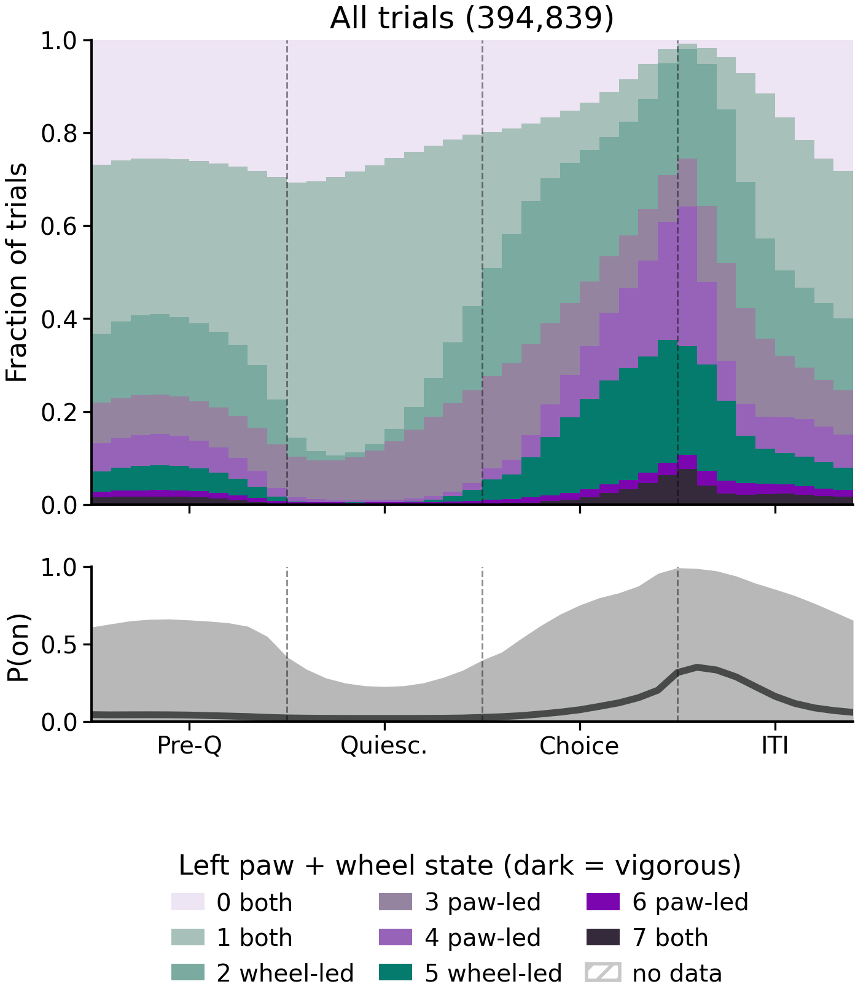

In [9]:
# The same for the whole dataset, for reference
_, all_codes = tm.trial_matrix_from_trials(trials)
fig, (ax, ax_wl) = plt.subplots(2, 1, figsize=(4, 3.6), height_ratios=[3, 1], sharex=True)
ps.syllable_histogram(all_codes, ax=ax); ps.whisk_lick_panel(all_codes, ax=ax_wl)
for a in (ax, ax_wl):
    ps.epoch_lines(a, all_codes.shape[1])
ax.set_title(f'All trials ({len(all_codes):,})')
ax_wl.set_xticks([5, 15, 25, 35], ps.EPOCH_SHORT)
state_legend(fig, ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.show()

## How the hyperparameters were chosen

They weren't selected by a criterion. Every value is the original notebook's, which were set by eye on
the proficient data: UMAP at its defaults (`n_neighbors=15`, `min_dist=0.1`), the KDE at scipy's
default bandwidth (Scott's rule), background = below the KDE's 60th percentile, and watershed peaks
at least 10 grid pixels apart.

The sweep below re-runs only the KDE-to-watershed step on the cached embedding. On this data the count
does **not** depend on the two watershed knobs in their usual range: 14 modes for any `min_distance`
≤ 10 and any threshold (50-70th percentile); modes only start merging at 15 (12) and 20 (7-8). So the 14
is set upstream, by **how smooth the KDE is (its bandwidth) and by the UMAP layout** — neither of
which was tuned.

Whether the modes themselves are stable (UMAP seed,
`n_neighbors`, a different subsample of sessions) needs the UMAP re-run, ~4 min each.

In [10]:
emb = trials[['embedding_x', 'embedding_y']].dropna().to_numpy()
rows = []
for thr in [50, 60, 70]:
    for md_ in [5, 8, 10, 15, 20]:
        L = tm.watershed_map(res['Z'], threshold_pct=thr, min_distance=md_)
        lab = tm.assign(emb, L, res['bounds'])
        sizes = pd.Series(lab).value_counts(normalize=True)
        rows.append({'threshold_pct': thr, 'min_distance': md_, 'n_modes': L.max(),
                     'background': np.isnan(lab).mean(), 'smallest_mode': sizes.min()})
sweep = pd.DataFrame(rows)
sweep.pivot(index='min_distance', columns='threshold_pct', values='n_modes')

threshold_pct,50,60,70
min_distance,,,
5,14,14,14
8,14,14,14
10,14,14,14
15,12,12,11
20,8,8,7


## Mode usage per mouse and per NM

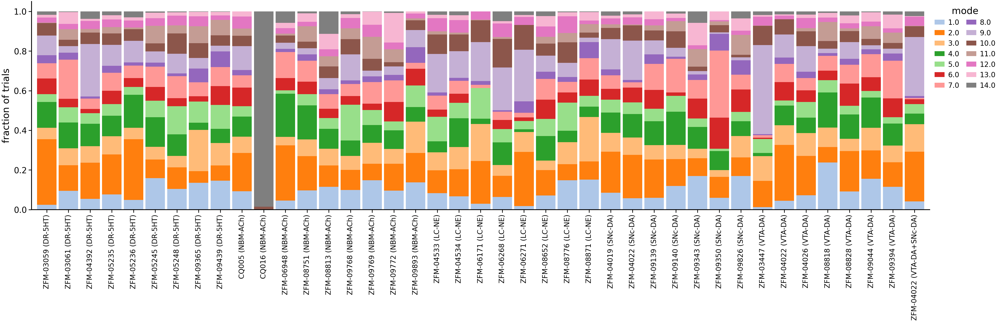

In [11]:
usage = (trials.dropna(subset=['trial_cluster'])
         .groupby(['NM', 'mouse_name'])['trial_cluster'].value_counts(normalize=True)
         .unstack(fill_value=0))
usage = usage.reindex(sorted(usage.index, key=lambda i: (nm_order.index(i[0]) if i[0] in nm_order else 99, i[1])))
cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(12, 4))
usage.plot.bar(stacked=True, ax=ax, width=.9, color=[cmap(int(k) % 20) for k in usage.columns], legend=False)
ax.set_xticklabels([f'{m} ({nm})' for nm, m in usage.index], fontsize=6)
ax.set(ylabel='fraction of trials', xlabel='')
ax.legend(title='mode', bbox_to_anchor=(1, 1), fontsize=6, frameon=False, ncol=2)
sns.despine(); plt.tight_layout()

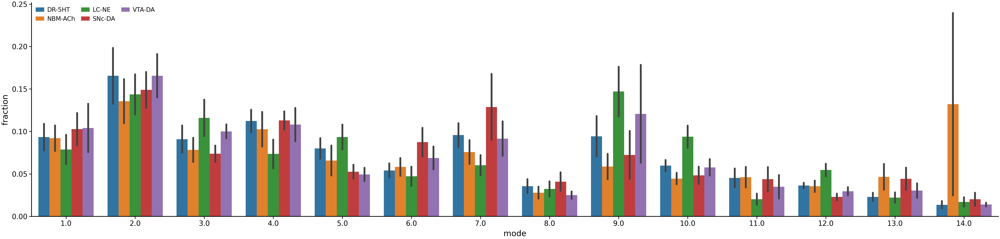

In [12]:
# per-NM usage, mouse as unit (NM is a between-mouse factor)
u = usage.reset_index().melt(id_vars=['NM', 'mouse_name'], var_name='mode', value_name='fraction')
fig, ax = plt.subplots(figsize=(14, 3.5))
sns.barplot(data=u, x='mode', y='fraction', hue='NM', hue_order=nm_order, ax=ax, errorbar='se')
ax.legend(fontsize=6, frameon=False, ncol=3)
sns.despine(); plt.tight_layout()

## Modes and task variables

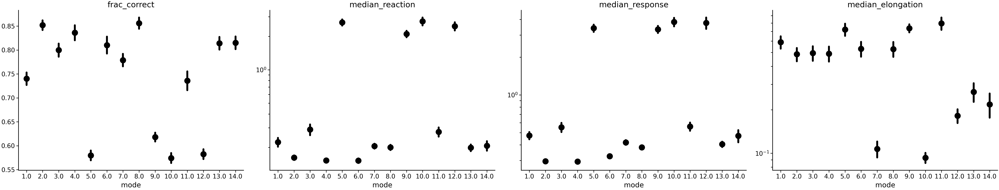

In [13]:
d = trials.dropna(subset=['trial_cluster'])
per_mouse = (d.groupby(['mouse_name', 'trial_cluster'])
             .agg(frac_correct=('correct', 'mean'), median_reaction=('reaction', 'median'),
                  median_response=('response', 'median'), median_elongation=('elongation', 'median'),
                  n=('correct', 'size'))
             .reset_index())
per_mouse = per_mouse[per_mouse['n'] >= 20]   # a mode needs a few trials in a mouse to give that mouse a value
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharex=True)
for ax, m in zip(axes, ['frac_correct', 'median_reaction', 'median_response', 'median_elongation']):
    sns.pointplot(data=per_mouse, x='trial_cluster', y=m, ax=ax, errorbar='se', linestyle='none', color='k')
    ax.set(title=m, xlabel='mode', ylabel='')
    ax.tick_params(axis='x', labelsize=7)
    if m != 'frac_correct':
        ax.set_yscale('log')
sns.despine(); plt.tight_layout()

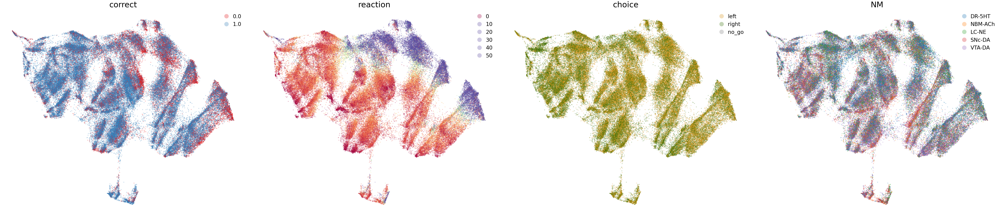

In [14]:
# Where task variables sit on the embedding (subsample for plotting)
p = trials.dropna(subset=['embedding_x', 'correct']).sample(100_000, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (col, kw) in zip(axes, [('correct', dict(palette=['#e41a1c', '#377eb8'])),
                                ('reaction', dict(palette='Spectral', hue_norm=(0, 1))),
                                ('choice', dict(palette=['#D8971F', '#39720B', 'grey'])),
                                ('NM', dict(hue_order=nm_order))]):
    sns.scatterplot(data=p, x='embedding_x', y='embedding_y', hue=col, s=1, alpha=.3, linewidth=0,
                    ax=ax, rasterized=True, **kw)
    ax.set(title=col, xlabel='', ylabel=''); ax.axis('off')
    ax.legend(fontsize=6, frameon=False, markerscale=5)
plt.tight_layout()